In [1]:
import sys
import os 
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("../../"))
sys.path.append(os.path.abspath("../3_Helpers"))
from optimizer import variables

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
optimization_output = pd.read_csv("Optimization_data/optimization_results_bess_pv_price_100.csv").iloc[:,:4]

In [63]:
optimization_output[:10]

,price_col,gen_scenario,bess_duration_h,sum_actual_revenue_row_total
0,Year 1,0,2.0,9.202863e+05
1,Year 1,0,2.5,1.038572e+06
2,Year 1,0,3.0,1.106216e+06
3,Year 1,0,3.5,1.165870e+06
4,Year 1,0,4.0,1.204741e+06
5,Year 1,0,4.5,1.228436e+06
6,Year 1,0,5.0,1.242489e+06
7,Year 1,0,5.5,1.253506e+06
8,Year 1,0,6.0,1.262667e+06
9,Year 1,0,6.5,1.269694e+06


In [4]:
optimization_output[optimization_output['gen_scenario'] == 7].groupby('bess_duration_h')['sum_actual_revenue_row_total'].quantile([0.05, 0.50, 0.95]).unstack()

KeyError: 'gen_scenario'

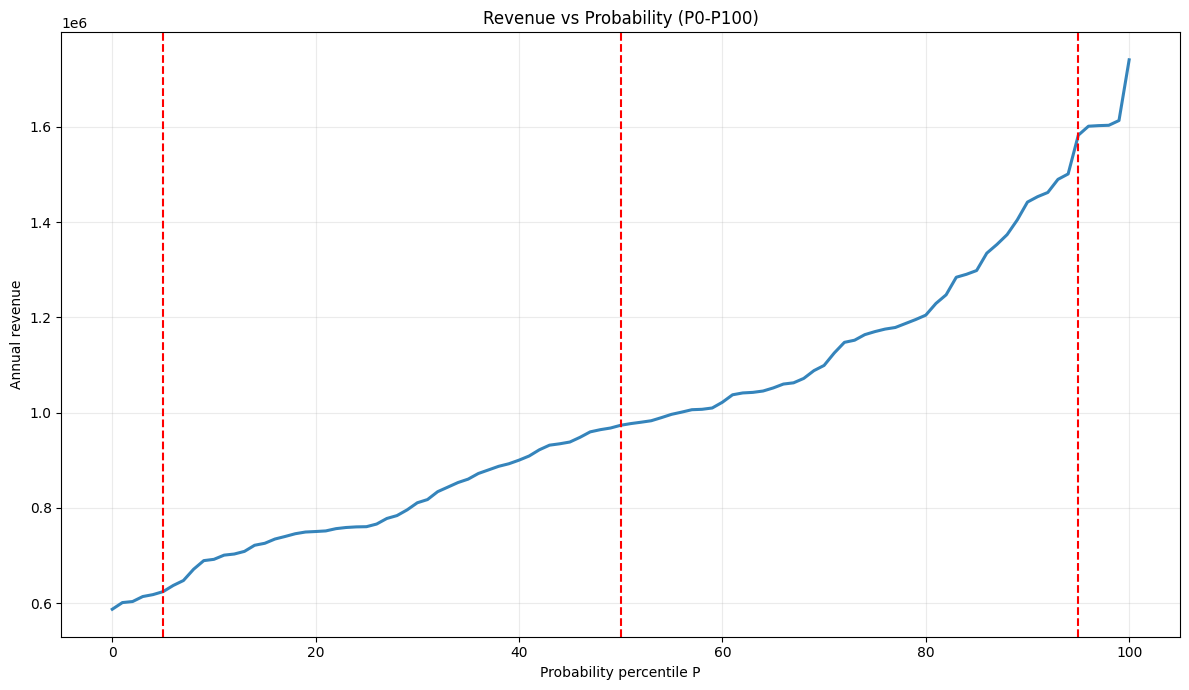

In [65]:
import matplotlib.pyplot as plt

durations=[1, 2, 4],
scenarios=[7],

p_grid = np.arange(0, 101, 1)

optimization_output = optimization_output[['bess_duration_h', 'gen_scenario', 'sum_actual_revenue_row_total']].dropna().copy()
optimization_output = optimization_output[optimization_output['bess_duration_h']==4]
optimization_output = optimization_output[optimization_output['gen_scenario']==3]


fig, ax = plt.subplots(figsize=(12, 7))

for (duration, scenario), g in optimization_output.groupby(['bess_duration_h', 'gen_scenario'], sort=True):
    y = np.percentile(g['sum_actual_revenue_row_total'].to_numpy(), p_grid)
    ax.plot(
        p_grid,
        y,
        linewidth=2.2,
        alpha=0.9,
        label=f'duration={duration}h | gen_scenario={scenario}',
    )

ax.set_title('Revenue vs Probability (P0-P100)')
ax.set_xlabel('Probability percentile P')
ax.set_ylabel('Annual revenue')
ax.grid(True, alpha=0.25)
# ax.legend(loc='best', ncol=1, fontsize=9)
ax.axvline(x=5,linestyle='--',color='red')
ax.axvline(x=50,linestyle='--',color='red')
ax.axvline(x=95,linestyle='--',color='red')
plt.tight_layout()


